2. МАТРИЦА СМЕЖНОСТИ
Вершины: Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec 
----------------------------------------------------------------------
Jan:    0    4    0    0    0    0    0    2    0    3    0    0
Feb:    0    0    3    0    0    5    0    0    0    0    0    0
Mar:    0    0    0    0    0    0    0    0    0    0    1    0
Apr:    0    7    2    0    0    0    0    0    0    0    0    0
May:    0    0    0    8    0    0    0    0    0    0    0    0
Jun:    0    0    0    0    7    0    3    0    0    0    0    0
Jul:    5    3    0    0    0    0    0    0    0    0    0    0
Aug:    0    0    0    0    0    0    0    0    0    0    0    0
Sep:    0    0    0    0    0    2    1    0    0    0    0    0
Oct:    0    0    0    0    0    0    0    0    6    0    0    0
Nov:    0    0    0    0    0    0    0    0    0    0    0    4
Dec:    0    0    0    1    0    0    0    0    0    0    0    0

3. СПИСОК РЕБЕР
 1. Jan -> Feb (вес: 4)
 2. Jan -> Aug (ве

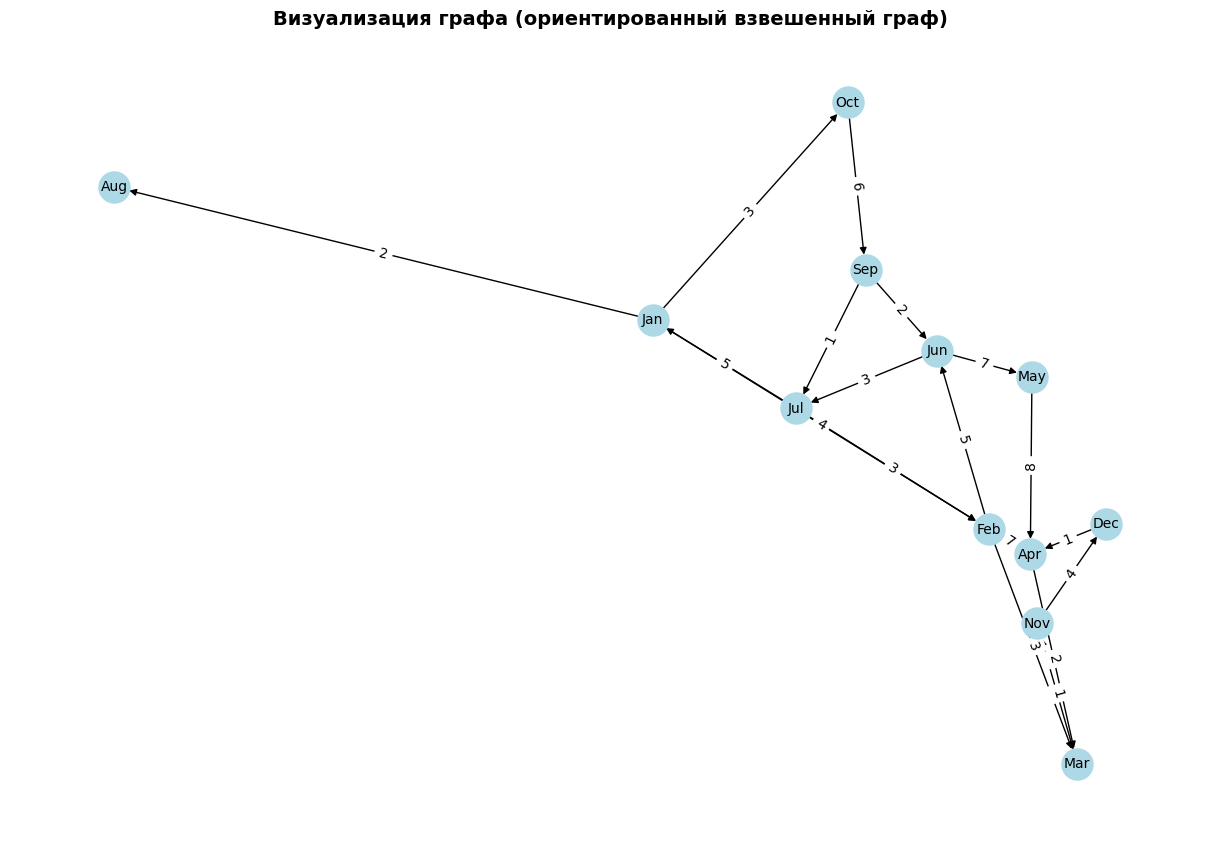


7. РАЗМЕР ОБЪЕКТОВ В БАЙТАХ
Матрица смежности: 152 байт
Список ребер: 248 байт
Массив записей: 184 байт

8. СРЕДНЕЕ ВРЕМЯ ВЫПОЛНЕНИЯ (10^5 итераций)

МАТРИЦА СМЕЖНОСТИ (время в мкс):
  Поиск соседей: 1.10 мкс
  Проверка цепи: 1.59 мкс
  Сумма весов > порога: 29.49 мкс
  Подсчет ребер: 20.90 мкс

СПИСОК РЕБЕР (время в мкс):
  Поиск соседей: 2.44 мкс
  Проверка цепи: 2.98 мкс
  Сумма весов > порога: 10.28 мкс
  Подсчет ребер: 0.10 мкс

МАССИВ ЗАПИСЕЙ (время в мкс):
  Поиск соседей: 0.37 мкс
  Проверка цепи: 4.31 мкс
  Сумма весов > порога: 3.97 мкс
  Подсчет ребер: 1.79 мкс
6. ДЕМОНСТРАЦИЯ РАБОТЫ ПОДПРОГРАММ
Тестовая вершина: Jan
Тестовая последовательность: Jan -> Feb -> Jun -> Jul
Порог для суммы весов: 10
----------------------------------------------------------------------
МАТРИЦА СМЕЖНОСТИ:
  Соседи Jan: ['Feb', 'Aug', 'Oct']
  Является цепью: True
  Вершины с суммой весов > 10: ['Jan', 'Feb', 'Apr', 'May', 'Jun', 'Jul']
  Количество ребер: 18

СПИСОК РЕБЕР:
  Соседи Jan: ['Feb', 

In [16]:
import sys
import time
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

# ============================================================================
# 2. Матрица смежности в явном виде
# ============================================================================

# Исходная матрица смежности
adjacency_matrix = [
    [0, 4, 0, 0, 0, 0, 0, 2, 0, 3, 0, 0],  # Jan
    [0, 0, 3, 0, 0, 5, 0, 0, 0, 0, 0, 0],  # Feb
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],  # Mar
    [0, 7, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Apr
    [0, 0, 0, 8, 0, 0, 0, 0, 0, 0, 0, 0],  # May
    [0, 0, 0, 0, 7, 0, 3, 0, 0, 0, 0, 0],  # Jun
    [5, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Jul
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Aug
    [0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0],  # Sep
    [0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0],  # Oct
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4],  # Nov
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]   # Dec
]

vertex_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
n = len(vertex_names)

print("=" * 70)
print("2. МАТРИЦА СМЕЖНОСТИ")
print("=" * 70)
print("Вершины:", " ".join(f"{name:4}" for name in vertex_names))
print("-" * 70)
for i in range(n):
    row_str = " ".join(f"{adjacency_matrix[i][j]:4}" for j in range(n))
    print(f"{vertex_names[i]}: {row_str}")
print()

# ============================================================================
# 3. Подпрограмма для построения списка ребер
# ============================================================================

def build_edge_list(adj_matrix, names):
    edges = []
    n = len(adj_matrix)
    for i in range(n):
        for j in range(n):
            if adj_matrix[i][j] > 0:
                edges.append((names[i], names[j], adj_matrix[i][j]))
    return edges

print("=" * 70)
print("3. СПИСОК РЕБЕР")
print("=" * 70)
edges = build_edge_list(adjacency_matrix, vertex_names)
for i, (from_vertex, to_vertex, weight) in enumerate(edges, 1):
    print(f"{i:2}. {from_vertex} -> {to_vertex} (вес: {weight})")
print(f"Всего ребер: {len(edges)}")
print()

# ============================================================================
# 4. Массив записей (структура вершин)
# ============================================================================

class VertexRecord:
    """Запись для представления вершины графа"""
    def __init__(self, index, name):
        self.index = index          # Индекс вершины
        self.name = name            # Имя вершины
        self.predecessors = []       # Предки (от кого приходят ребра)
        self.successors = []         # Потомки (к кому идут ребра)
        self.in_weights = []         # Веса входящих ребер
        self.out_weights = []        # Веса исходящих ребер
        
    def __str__(self):
        pred_str = ", ".join([f"{p}({w})" for p, w in self.predecessors]) or "нет"
        succ_str = ", ".join([f"{s}({w})" for s, w in self.successors]) or "нет"
        return (f"Индекс: {self.index:2} | Имя: {self.name:4} | "
                f"Предки: {pred_str:30} | Потомки: {succ_str}")

def build_vertex_records(adj_matrix, names):
    n = len(adj_matrix)
    records = []
    
    for i in range(n):
        record = VertexRecord(i, names[i])
        
        # Поиск предков (входящие ребра)
        for j in range(n):
            if adj_matrix[j][i] > 0:
                record.predecessors.append((names[j], adj_matrix[j][i]))
                record.in_weights.append(adj_matrix[j][i])
        
        # Поиск потомков (исходящие ребра)
        for j in range(n):
            if adj_matrix[i][j] > 0:
                record.successors.append((names[j], adj_matrix[i][j]))
                record.out_weights.append(adj_matrix[i][j])
        
        records.append(record)
    
    return records

print("=" * 70)
print("4. МАССИВ ЗАПИСЕЙ ВЕРШИН")
print("=" * 70)
vertex_records = build_vertex_records(adjacency_matrix, vertex_names)
for record in vertex_records:
    print(record)
print()

# ============================================================================
# 5. Визуализация графа
# ============================================================================

def visualize_graph(names, edges=edges):
    G = nx.DiGraph()
    G.add_nodes_from(names)
    G.add_weighted_edges_from(edges)
    
    pos = nx.spring_layout(G)
    plt.figure(figsize=(12, 8))

    nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=500, font_size=10, arrows=True)
    
    edge_labels = {(u, v): w for u, v, w in edges}
    
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    
    plt.title("Визуализация графа (ориентированный взвешенный граф)", 
              fontsize=14, fontweight='bold')
    plt.show()

print("=" * 70)
print("5. ВИЗУАЛИЗАЦИЯ ГРАФА")
print("=" * 70)
print("Граф визуализирован в отдельном окне.")
visualize_graph(vertex_names)
print()

# ============================================================================
# 6. Подпрограммы для каждого представления
# ============================================================================

class GraphRepresentations:
    """Класс для работы с различными представлениями графа"""
    
    def __init__(self, adj_matrix, names):
        self.adj_matrix = adj_matrix
        self.names = names
        self.n = len(adj_matrix)
        self.edges = build_edge_list(adj_matrix, names)
        self.vertex_records = build_vertex_records(adj_matrix, names)
    
    # ========== РАБОТА С МАТРИЦЕЙ СМЕЖНОСТИ ==========
    
    def matrix_neighbors(self, vertex):
        """Поиск соседей заданной вершины (матрица)"""
        idx = self.names.index(vertex)
        neighbors = []
        for j in range(self.n):
            if self.adj_matrix[idx][j] > 0:
                neighbors.append(self.names[j])
        return neighbors
    
    def matrix_is_chain(self, sequence):
        """Проверка, является ли последовательность цепью (матрица)"""
        for i in range(len(sequence) - 1):
            from_idx = self.names.index(sequence[i])
            to_idx = self.names.index(sequence[i + 1])
            if self.adj_matrix[from_idx][to_idx] == 0:
                return False
        return True
    
    def matrix_sum_weights_gt(self, threshold):
        """Вершины с суммой весов смежных ребер > threshold (матрица)"""
        result = []
        for i in range(self.n):
            total = sum(self.adj_matrix[i][j] + self.adj_matrix[j][i] 
                       for j in range(self.n))
            if total > threshold:
                result.append(self.names[i])
        return result
    
    def matrix_count_edges(self):
        """Подсчет количества ребер (матрица)"""
        count = 0
        for i in range(self.n):
            for j in range(self.n):
                if self.adj_matrix[i][j] > 0:
                    count += 1
        return count
    
    # ========== РАБОТА СО СПИСКОМ РЕБЕР ==========
    
    def edge_neighbors(self, vertex):
        """Поиск соседей заданной вершины (список ребер)"""
        neighbors = []
        for from_v, to_v, _ in self.edges:
            if from_v == vertex:
                neighbors.append(to_v)
        return neighbors
    
    def edge_is_chain(self, sequence):
        """Проверка, является ли последовательность цепью (список ребер)"""
        edges_set = {(f, t) for f, t, _ in self.edges}
        for i in range(len(sequence) - 1):
            if (sequence[i], sequence[i + 1]) not in edges_set:
                return False
        return True
    
    def edge_sum_weights_gt(self, threshold):
        """Вершины с суммой весов смежных ребер > threshold (список ребер)"""
        weight_sum = defaultdict(int)
        for from_v, to_v, weight in self.edges:
            weight_sum[from_v] += weight
            weight_sum[to_v] += weight
        
        return [v for v, s in weight_sum.items() if s > threshold]
    
    def edge_count_edges(self):
        """Подсчет количества ребер (список ребер)"""
        return len(self.edges)
    
    # ========== РАБОТА С МАССИВОМ ЗАПИСЕЙ ==========
    
    def record_neighbors(self, vertex):
        """Поиск соседей заданной вершины (массив записей)"""
        for record in self.vertex_records:
            if record.name == vertex:
                return [succ for succ, _ in record.successors]
        return []
    
    def record_is_chain(self, sequence):
        """Проверка, является ли последовательность цепью (массив записей)"""
        successors_dict = {}
        for record in self.vertex_records:
            successors_dict[record.name] = {succ for succ, _ in record.successors}
        
        for i in range(len(sequence) - 1):
            if sequence[i + 1] not in successors_dict.get(sequence[i], set()):
                return False
        return True
    
    def record_sum_weights_gt(self, threshold):
        """Вершины с суммой весов смежных ребер > threshold (массив записей)"""
        result = []
        for record in self.vertex_records:
            total = sum(record.out_weights) + sum(record.in_weights)
            if total > threshold:
                result.append(record.name)
        return result
    
    def record_count_edges(self):
        """Подсчет количества ребер (массив записей)"""
        return sum(len(record.successors) for record in self.vertex_records)
    
    # ========== ВЫВОД РЕЗУЛЬТАТОВ ПОДПРОГРАММ ==========
    
    def demonstrate_functions(self):
        """Демонстрация работы всех подпрограмм"""
        print("=" * 70)
        print("6. ДЕМОНСТРАЦИЯ РАБОТЫ ПОДПРОГРАММ")
        print("=" * 70)
        
        test_vertex = "Jan"
        test_chain = ["Jan", "Feb", "Jun", "Jul"]
        test_threshold = 10
        
        print(f"Тестовая вершина: {test_vertex}")
        print(f"Тестовая последовательность: {' -> '.join(test_chain)}")
        print(f"Порог для суммы весов: {test_threshold}")
        print("-" * 70)
        
        # Матрица смежности
        print("МАТРИЦА СМЕЖНОСТИ:")
        print(f"  Соседи {test_vertex}: {self.matrix_neighbors(test_vertex)}")
        print(f"  Является цепью: {self.matrix_is_chain(test_chain)}")
        print(f"  Вершины с суммой весов > {test_threshold}: {self.matrix_sum_weights_gt(test_threshold)}")
        print(f"  Количество ребер: {self.matrix_count_edges()}")
        print()
        
        # Список ребер
        print("СПИСОК РЕБЕР:")
        print(f"  Соседи {test_vertex}: {self.edge_neighbors(test_vertex)}")
        print(f"  Является цепью: {self.edge_is_chain(test_chain)}")
        print(f"  Вершины с суммой весов > {test_threshold}: {self.edge_sum_weights_gt(test_threshold)}")
        print(f"  Количество ребер: {self.edge_count_edges()}")
        print()
        
        # Массив записей
        print("МАССИВ ЗАПИСЕЙ:")
        print(f"  Соседи {test_vertex}: {self.record_neighbors(test_vertex)}")
        print(f"  Является цепью: {self.record_is_chain(test_chain)}")
        print(f"  Вершины с суммой весов > {test_threshold}: {self.record_sum_weights_gt(test_threshold)}")
        print(f"  Количество ребер: {self.record_count_edges()}")
        print()

# ============================================================================
# 7. Размер объектов в байтах
# ============================================================================

print("=" * 70)
print("7. РАЗМЕР ОБЪЕКТОВ В БАЙТАХ")
print("=" * 70)

graph = GraphRepresentations(adjacency_matrix, vertex_names)

# Размер матрицы смежности
matrix_size = sys.getsizeof(adjacency_matrix)
print(f"Матрица смежности: {matrix_size} байт")

edges_size = sys.getsizeof(edges)
print(f"Список ребер: {edges_size} байт")

records_size = sys.getsizeof(graph.vertex_records)
print(f"Массив записей: {records_size} байт")
print()

# ============================================================================
# 8. Среднее время выполнения подпрограмм
# ============================================================================

def measure_time(func, *args, iterations):
    """Измерение среднего времени выполнения функции"""
    start_time = time.perf_counter()
    for _ in range(iterations):
        func(*args)
    end_time = time.perf_counter()
    return (end_time - start_time) / iterations

print("=" * 70)
print("8. СРЕДНЕЕ ВРЕМЯ ВЫПОЛНЕНИЯ (10^5 итераций)")
print("=" * 70)

iterations = 10 ** 5
test_vertex = "Jan"
test_chain = ["Jan", "Feb", "Jun", "Jul"]
test_threshold = 10

# Матрица смежности
print("\nМАТРИЦА СМЕЖНОСТИ (время в мкс):")
t1 = measure_time(graph.matrix_neighbors, test_vertex, iterations=iterations) * 1_000_000
print(f"  Поиск соседей: {t1:.2f} мкс")
t2 = measure_time(graph.matrix_is_chain, test_chain, iterations=iterations) * 1_000_000
print(f"  Проверка цепи: {t2:.2f} мкс")
t3 = measure_time(graph.matrix_sum_weights_gt, test_threshold, iterations=iterations) * 1_000_000
print(f"  Сумма весов > порога: {t3:.2f} мкс")
t4 = measure_time(graph.matrix_count_edges, iterations=iterations) * 1_000_000
print(f"  Подсчет ребер: {t4:.2f} мкс")

# Список ребер
print("\nСПИСОК РЕБЕР (время в мкс):")
t1 = measure_time(graph.edge_neighbors, test_vertex, iterations=iterations) * 1_000_000
print(f"  Поиск соседей: {t1:.2f} мкс")
t2 = measure_time(graph.edge_is_chain, test_chain, iterations=iterations) * 1_000_000
print(f"  Проверка цепи: {t2:.2f} мкс")
t3 = measure_time(graph.edge_sum_weights_gt, test_threshold, iterations=iterations) * 1_000_000
print(f"  Сумма весов > порога: {t3:.2f} мкс")
t4 = measure_time(graph.edge_count_edges, iterations=iterations) * 1_000_000
print(f"  Подсчет ребер: {t4:.2f} мкс")

# Массив записей
print("\nМАССИВ ЗАПИСЕЙ (время в мкс):")
t1 = measure_time(graph.record_neighbors, test_vertex, iterations=iterations) * 1_000_000
print(f"  Поиск соседей: {t1:.2f} мкс")
t2 = measure_time(graph.record_is_chain, test_chain, iterations=iterations) * 1_000_000
print(f"  Проверка цепи: {t2:.2f} мкс")
t3 = measure_time(graph.record_sum_weights_gt, test_threshold, iterations=iterations) * 1_000_000
print(f"  Сумма весов > порога: {t3:.2f} мкс")
t4 = measure_time(graph.record_count_edges, iterations=iterations) * 1_000_000
print(f"  Подсчет ребер: {t4:.2f} мкс")

# Демонстрация работы функций
graph.demonstrate_functions()
